This file contains all code for generating the graphs and (partial) tables for the paper.

# Preprocessing

In [14]:
# Imports & stuff

import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
from IPython.display import display, HTML
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.colors as cls
from cycler import cycler
from scipy.signal import savgol_filter

# Constants
time = 3600
discount = 0.95
pres_sarsop = []
pres_ub = []
# all_envs = ["ABC", "Tiger", "RockSample5", "RockSample10", "K-out-of-N2", "K-out-of-N3", 
#             "FrozenLake4", "FrozenLake10", "Tag", "Hallway1", "Hallway2", "MiniHallway", "TigerGrid"] # All envs
# all_envs = ["ABC", "Tiger","grid", "RockSample5", "RockSample7", "DroneSurveilance", "iff", "baseball",
            #  "K-out-of-N2", "K-out-of-N3", "aloha30", "Tag",  "SparseTigerGrid", "SparseHallway1", 
            #  "SparseHallway2", "pentagon", "fourth","iff", "baseball",]
all_envs = ["ABC", "Tiger", "RockSample5", "baseball", "DroneSurveilance",                  # Solvable by Sarsop in <20min
            "K-out-of-N2", "K-out-of-N3", "grid", "RockSample7", "Tag", "iff",  "aloha30",  # Non-navigation
            "SparseTigerGrid", "SparseHallway1", "SparseHallway2", "pentagon", "fourth",    # Navigation, small to large
             ]
# Missing: "sunysb", "fourth" (Never run) & 

# all_envs = ["ABC", "Tiger", "RockSample5", "K-out-of-N2", "K-out-of-N3", 
#             "FrozenLake4", "FrozenLake10", "Tag",  "SparseHallway1", "SparseHallway2", "SparseTigerGrid"] # Messing around...
Env_to_latex_name = {
    "ABC" : "\\custom",
    "Tiger":"\\tiger",
    "RockSample5": "\\rocksamplefive",
    "RockSample10": "\\rocksampleten",
    "RockSample11": "\\rocksampleeleven",
    "RockSample7": "\\rocksampleeight",
    "K-out-of-N2":"\\koutofntwo",
    "K-out-of-N3":"\\koutofnthree",
    "FrozenLake4":"\\lake (4)",
    "FrozenLake10":"\\lake (10)",
    "Tag":"\\tagenv",
    "Hallway1":"\\hallway1",
    "Hallway2":"\\hallway2",
    "TigerGrid":"\\tigergrid",
    "Sparse_Hallway1":"\\hallwayone",
    "Sparse_Hallway2":"\\hallwaytwo",
    "SparseHallway1":"\\hallwayone",
    "SparseHallway2":"\\hallwaytwo",
    "SparseTigerGrid":"\\tigergrid",
    "MiniHallway":"\\minihallway",
    "aloha10":"\\alohaten", 
    "aloha30":"\\alohathirty", 
    "cit":"\\cit", 
    "fourth":"\\fourth", 
    "mit":"\\mit", 
    "pentagon":"\\pentagon", 
    "sunysb":"\\sunysb", 
    "grid":"\\gridenv",
    "DroneSurveilance":"\\drone",
    "iff":"\\iffenv",
    "baseball":"\\baseball"
}

solver_to_heuristic = {
    "SARSOP" : "FIB",
    "CTIB-SARSOP" : "CTIB",
    "TIB-SARSOP" : "TIB",
    "ETIB-SARSOP" : "ETIB",
    "MultiTIB-SARSOP": "MultiTIB"
}



# all_envs = ["ABC", "Tiger", "RockSample5", "FrozenLake4"] #Testing envs
# all_envs = ["ABC", "Tiger", "RockSample5", "FrozenLake4", "FrozenLake10", "K-out-of-N3"] #Testing envs
pre_sarsop = "./Data/SarsopTest/Sarsoptest_"
pre_ub = "./Data/UpperBounds/UpperBoundTest_"
post_sarsop = f"_t{time}_d{str(discount)[2:]}_OnlyBs.json"
# post_sarsop = f"_t{time}_d{str(discount)[2:]}.json"
post_ub =f"_d{str(discount)[2:]}.json"
for env in all_envs:
    pres_ub.append(pre_ub + env + "_")

# solvers = ["SARSOP", "TIB-SARSOP", "ETIB-SARSOP"]
GLOBAL_SOLVERS = ["SARSOP", "TIB-SARSOP", "CTIB-SARSOP", "ETIB-SARSOP", "MultiTIB-SARSOP" ]
# solvers = ["SARSOP", "TIB-SARSOP"]

def get_data_plot(env:str, solvers=GLOBAL_SOLVERS):
    ts, ubs, lbs = [], [], []
    solvernames, envname = [], ""
    for s in solvers:
        filename = pre_sarsop+env+"_"+s+post_sarsop
        with open(filename) as file:
            data = json.load(file)
            ts.append(data["times"])
            ubs.append(data["ubs"])
            lbs.append(data["lbs"])
            solvernames.append(data["solver"])
            envname = data["env_full"]

    return ts, ubs, lbs, solvernames, envname


def get_data_discounts(env, discounts):
    times, init_times = [], []
    solvernames = []
    for (s_idx, s) in enumerate(solvers):
        solvernames.append(s)
        times.append([])
        init_times.append([])
        for (d_idx, d) in enumerate(discounts):
            filename = f'./Data/DiscountTest/Sarsoptest_{env}_{s}_t{time}_d{str(round(d, 4))[2:]}.json'
            with open(filename) as file:
                data = json.load(file)
                thistime = data["runtime"]
                if thistime <= 3600:
                    times[s_idx].append(thistime)
                    init_times[s_idx].append(data["times"][0])
                else:
                    for i in range(len(discounts)-d_idx):
                        times[s_idx].append(3600)
                    break

    return times, init_times, solvernames


def size_to_string(size:int):
    if size < 1000:
        return str(size)
    elif size < 10_000:
        return f'{(size/1_000):.1f}k'
    return f'{(size/1_000):.0f}k'

def value_to_string(nmbr:float):
    if abs(nmbr) < 10:
        return f'{nmbr:.2f}'
    elif abs(nmbr) < 100:
        return f'{nmbr:.1f}'
    else:
        return f'{nmbr:.0f}'
    
def time_to_string(nmbr:float, timeout=np.inf):
    if nmbr > timeout:
        return "TO"
    elif nmbr < 0.5:
        return "${<}$1s"
    elif nmbr < 100:
        return f'{nmbr:.0f}s'
    else:
        return f'{nmbr:.0f}s'



# Tables

## SARSOP - Large & Small

In [ ]:
# SARSOP Convergence test - Large

def get_valuebounds_sarsop(data:dict, tmax, addAnd=False):
    times, ubs, lbs = data["times"], data["ubs"], data["lbs"]
    for (i, t) in enumerate(times):
        if t > tmax:
            if i == 0:
                return "N/A"
            # diff = abs(( ubs[i] - lbs[i]) / ubs[i])
            diff = round(abs(( ubs[i-1] - lbs[i-1]) / lbs[i-1]), 2)
            # diff =  f'{lbs[i-1]:.2f}, {ubs[i-1]:.2f}'
            break
            # diff =  f'{lbs[i-1]:.2f}, {ubs[i-1]:.2f} '
    # diff = abs(( data["final_ub"] - data["final_lw"]) / data["final_ub"])
    # diff = abs(( data["final_ub"] - data["final_lw"]) / data["final_lb"])
    return diff


# labels = ["\\SARSOP", "\\TIBSARSOP", "\\ETIBSARSOP"]
# labels = ["\\FIB", "", "\\TIB","", "\\ETIB",""]
# labels = ["900s", "1800s", "3600s", "900s", "1800s", "3600s","900s", "1800s", "3600s"]
# labels = np.tile(["\\FIB", "\\BIB","\\CBIB","\\EBIB", "\\EBIB"], 3)
# filenames = ["SARSOP", "TIB-SARSOP", "CTIB-SARSOP", "ETIB-SARSOP", "EBIB-SARSOP"]
labels = np.tile(["\\FIB", "\\BIB","\\CBIB", "\\EBIB"], 3)
filenames = ["SARSOP", "TIB-SARSOP", "CTIB-SARSOP", "ETIB-SARSOP"]
# labels = ["15 min", "30 min", "60 min","15 min", "30 min", "60 min","15 min", "30 min", "60 min",]
names = []
Data = []
for _l in labels:
    Data.append([])


times = [600, 1200, 3600]

for env in all_envs:
    pres_sarsop.append(pre_sarsop + env + "_" )
# envs_sarsop = ["RockSample10","K-out-of-N3", "Tag","SparseHallway1", "SparseHallway2","SparseTigerGrid",
#                "cit", "fourth", "mit", "pentagon", "grid"]
envs_sarsop = ["K-out-of-N3","grid","RockSample7", "Tag", "iff",
               "SparseTigerGrid", "SparseHallway1", "SparseHallway2",  "pentagon", "fourth",  ]

for env in envs_sarsop:
    thispre = pre_sarsop + env + "_"

    # store temporary numeric + string data for this environment
    env_values = [[None]*len(filenames) for _ in times]
    env_strings = [[None]*len(filenames) for _ in times]
    for method_idx, method in enumerate(filenames):
        filename = thispre + method + post_sarsop
        with open(filename) as file:
            this_data = json.load(file)
            # add env name once
            if method_idx == 0:
                names.append(f'{Env_to_latex_name[this_data["env"]]} &')

            for time_idx, t in enumerate(times):
                val = get_valuebounds_sarsop(this_data, t)
                if val == "N/A":
                    rounded_val = np.inf
                else:
                    rounded_val = round(float(val), 2)
                env_values[time_idx][method_idx] = rounded_val
                env_strings[time_idx][method_idx] = val

    # compute minima per time (after rounding)
    time_mins = [min(vs) for vs in env_values]
    # now write entries
    for method_idx, method in enumerate(filenames):
        for time_idx, t in enumerate(times):
            data_idx = time_idx * len(filenames) + method_idx
            val = env_strings[time_idx][method_idx]
            rounded_val = env_values[time_idx][method_idx]
            entry = f"{{{val}}}"

            # bold if minimum (ties automatically handled)
            if rounded_val == time_mins[time_idx]:
                entry = f"\\textbf{{{entry}}}"

            # preserve original formatting behavior
            if method_idx == len(filenames) - 1 and time_idx != len(times)-1:
                entry += " &"
            Data[data_idx].append(entry)

# dataframe = pd.DataFrame([Sarsop_lb, Sarsop_ub, TIBSarsop_lb, TIBSarsop_ub,ETIBSarsop_lb, ETIBSarsop_ub,], index=labels, columns=names).transpose()

dataframe = pd.DataFrame(Data, index=labels, columns=names).transpose()


print(dataframe)

print(dataframe.to_latex())

                               \FIB             \BIB            \CBIB  \
\koutofnthree &              {0.21}  \textbf{{0.12}}  \textbf{{0.12}}   
\gridenv &                   {0.16}           {0.15}           {0.08}   
\rocksampleeight &           {0.23}  \textbf{{0.19}}           {0.22}   
\tagenv &                    {0.44}   \textbf{{0.4}}   \textbf{{0.4}}   
\iffenv &           \textbf{{0.07}}  \textbf{{0.07}}  \textbf{{0.07}}   
\tigergrid &                 {0.11}  \textbf{{0.08}}  \textbf{{0.08}}   
\hallwayone &                {0.21}  \textbf{{0.16}}  \textbf{{0.16}}   
\hallwaytwo &                 {1.7}  \textbf{{1.51}}  \textbf{{1.51}}   
\pentagon &                  {0.18}           {0.12}  \textbf{{0.11}}   
\fourth &           \textbf{{0.59}}           {0.61}           {0.69}   

                                \EBIB             \FIB             \BIB  \
\koutofnthree &     \textbf{{0.12}} &            {0.2}  \textbf{{0.11}}   
\gridenv &          \textbf{{0.07}} &         

In [19]:
# SARSOP Convergence test - Small

def get_time_per_iter(data:dict):
    if len(data["times"]) == 1:
        return "N/A"
    avg_time = (data["runtime"] - data["times"][0]) / (len(data["times"])-1)
    return f'{avg_time:.2e}s'

def get_perc_heuristic_time(data:dict):
    return (data["times"][0] / data["runtime"])

# labels = ["\\FIB", "", "\\TIB","", "\\ETIB","", "\\OTIB",""]
# filenames = [
#     "SARSOP",
#     "TIB-SARSOP",
#     "CTIB-SARSOP",
#     "ETIB-SARSOP",
#     "MultiTIB-SARSOP"
# ]
# labels = ["\\FIB", "\\TIB", "\\CTIB", "\\ETIB", "\\MultiTIB"]
filenames = [
    "SARSOP",
    "TIB-SARSOP",
    "CTIB-SARSOP",
    "ETIB-SARSOP",
]
labels = ["\\FIB", "\\TIB", "\\CTIB", "\\ETIB"]
# labels = ["T", "N_E","T", "N_E","T", "N_E", ]
names = []

Data = []
for _l in labels:
    Data.append([])

envs_sarsop = ["ABC","Tiger", "RockSample5", "baseball", "DroneSurveilance", "K-out-of-N2", "aloha30"]
# envs_sarsop = ["ABC","Tiger", "RockSample5", "FrozenLake4"]

# pres_sarsop = []
# for env in envs_sarsop:
#     pres_sarsop.append(pre_sarsop + env + "_" )



for env in envs_sarsop:
    thispre = pre_sarsop + env + "_"
    for method_idx, method in enumerate(filenames):
        filename = thispre + method + post_sarsop

        with open(filename) as file:
            this_data = json.load(file)

            # Add environment name once
            if method_idx == 0:
                names.append(Env_to_latex_name[this_data["env"]])
            entry = f'& {time_to_string(this_data["runtime"], 3600)}'
            Data[method_idx].append(entry)



print(Data)
# dataframe = pd.DataFrame([Sarsop_lb, Sarsop_ub, TIBSarsop_lb, TIBSarsop_ub,ETIBSarsop_lb, ETIBSarsop_ub,], index=labels, columns=names).transpose()

dataframe = pd.DataFrame( Data, index=labels, columns=names).transpose()


print(dataframe)

print(dataframe.to_latex())

[['& ${<}$1s', '& ${<}$1s', '& ${<}$1s', '& 9s', '& 15s', '& 573s', '& 25s'], ['& ${<}$1s', '& ${<}$1s', '& ${<}$1s', '& 11s', '& 11s', '& 103s', '& 14s'], ['& ${<}$1s', '& ${<}$1s', '& 1s', '& 12s', '& 11s', '& 106s', '& 52s'], ['& ${<}$1s', '& ${<}$1s', '& ${<}$1s', '& 14s', '& 10s', '& 100s', '& 522s']]
                      \FIB       \TIB      \CTIB      \ETIB
\custom          & ${<}$1s  & ${<}$1s  & ${<}$1s  & ${<}$1s
\tiger           & ${<}$1s  & ${<}$1s  & ${<}$1s  & ${<}$1s
\rocksamplefive  & ${<}$1s  & ${<}$1s       & 1s  & ${<}$1s
\baseball             & 9s      & 11s      & 12s      & 14s
\drone               & 15s      & 11s      & 11s      & 10s
\koutofntwo         & 573s     & 103s     & 106s     & 100s
\alohathirty         & 25s      & 14s      & 52s     & 522s
\begin{tabular}{lllll}
\toprule
 & \FIB & \TIB & \CTIB & \ETIB \\
\midrule
\custom & & ${<}$1s & & ${<}$1s & & ${<}$1s & & ${<}$1s \\
\tiger & & ${<}$1s & & ${<}$1s & & ${<}$1s & & ${<}$1s \\
\rocksamplefive & & 

## Upper bounds

In [18]:
# Upper bounds

def get_vars_ub(data:dict):
    if data["solver"] == "SARSOP":
        # return f'{data["ub"]:.2f}, ({data["solvetime"]:.1f}s)'
        if data["solvetime"] < 1200:
            return f'{data["ub"]:.2f}'
        else:
            return f'\\uline{{{data["ub"]:.2f}}}'
    else:
        if data["solvetime"] > 1200:
            return "TO"
        else:
            t = f'{data["solvetime"]:.1f}s'
        return f'{data["ub"]:.2f} ({t})'

heuristic_names = ["SARSOP", "FIB", "TIB", "CTIB", "ETIB","OTIB_pre", "MultiTIB_pre", "OTIB"]
# heuristic_names = ["FIB", "TIB", "ETIB", "SARSOP"]
labels = ["","$|\\states|$", "$|\\actions|$", "$|\\observations|$", "$|\\Bsao|$",  "$|\\Bbao|$"]   # SARSOP]


for _h in range(len(heuristic_names)):
    labels.extend(["","$\\bar{V}$", "$t$"])                                                                                 

# heuristic_names = ["FIB", "TIB", "ETIB", "SARSOP"]
# labels = ["\\FIB", "\\TIB", "\\ETIB", "\\SARSOP"]
env_names, S, A, O, Bsao, Bbao = [], [], [], [], [], []
bounds = []
times = []
for _h in heuristic_names:
    bounds.append([])
    times.append([])
for _e in pres_ub:
    env_names.append("")
    S.append(""); A.append("");O.append("")
    Bsao.append(""); Bbao.append("")

empty = np.repeat("", len(pres_ub))

for (heur_idx, name) in enumerate(heuristic_names):
    for (env_idx, thispre) in enumerate(pres_ub):
        
        filename = thispre + name + post_ub
        # try:
        with open(filename) as file:           
            this_data = json.load(file)
            env_names[env_idx] = Env_to_latex_name[this_data["env"]]
            # S[env_idx] = size_to_string(this_data["env_data"]["ns"])
            # A[env_idx] = size_to_string(this_data["env_data"]["na"])
            # O[env_idx] = size_to_string(this_data["env_data"]["no"])
            # Bsao[env_idx] = size_to_string(this_data["env_data"]["nb"])
            # Bbao[env_idx] = size_to_string(this_data["env_data"]["nbao"])

            lb, ub = value_to_string(this_data["lb"]), value_to_string(this_data["ub"])
            if name == "SARSOP":
                if this_data["solvetime"] < 1200:
                    bounds[heur_idx].append(f'\\underline{{{lb}}}')
                else:
                    bounds[heur_idx].append(f'{{{lb}}}')
            else:
                bounds[heur_idx].append(f'{{{ub}}}')

            times[heur_idx].append(time_to_string(this_data["solvetime"], timeout=1200))
        # except:
            # print("Error in ", filename, "!!!")
            # bounds[heur_idx].append('-')
            # times[heur_idx].append("TO")

print(np.shape(bounds))
print(np.shape(env_names))

# data = [empty, S, A, O, Bsao, Bbao, empty, bounds[0], times[0],empty, bounds[1], times[1],empty,bounds[2], times[2],empty,bounds[3], times[3],empty,bounds[4], times[4]]
data = [env_names, empty, bounds[0], times[0],empty, bounds[1], times[1],empty,bounds[2], times[2],empty,bounds[3], times[3],empty,bounds[4], times[4],empty,bounds[5], times[5], empty,bounds[6], times[6],empty,bounds[7], times[7]]
data = [env_names, empty, bounds[0],empty, bounds[1], times[1],empty,bounds[2], times[2],empty,bounds[3], times[3],empty,bounds[4], times[4],empty,bounds[5], times[5], empty,bounds[6], times[6],empty,bounds[7], times[7]]
# # data = [S, A, O, Bsao, Bbao, bounds[3], bounds[0], times[0], bounds[1], times[1], bounds[2], times[2]]

print(data)

# dataframe = pd.DataFrame( data, columns=env_names).transpose() #, index=labels, columns=env_names).transpose()
dataframe = pd.DataFrame(data).transpose() #, index=labels, columns=env_names).transpose()

import re
import numpy as np

# Indices of bound columns inside `data`
# data = [env_names, empty, bounds[0], times[0], empty, bounds[1], times[1], ...]
# Pattern: bounds are at positions 2,5,8,11,14,17,20
bound_col_indices = [4 + 3*i for i in range(len(heuristic_names)-1)]

def extract_number(cell):
    match = re.search(r'-?\d+\.?\d*', cell)
    if match:
        return float(match.group())
    return None

# Iterate over rows
for row_idx in range(len(dataframe)):

    values = []
    for col_idx in bound_col_indices:
        cell = str(dataframe.iat[row_idx, col_idx])
        num = extract_number(cell)
        values.append(num)

    # Remove None values
    valid_vals = [v for v in values if v is not None]
    if not valid_vals:
        continue

    min_val = min(valid_vals)

    # Bold all tied maxima
    for i, col_idx in enumerate(bound_col_indices):
        if values[i] == min_val:
            current = dataframe.iat[row_idx, col_idx]
            dataframe.iat[row_idx, col_idx] = f'\\textbf{{{current}}}'

display(dataframe)

# print(dataframe.to_latex(column_format="l||rrrrr||r|rcrrcrrcrrcr",))
print(dataframe.to_latex( index=False))

# data_CTIB = [empty, bounds[2], times[2],empty,bounds[5], times[5],empty,bounds[3], times[3]]
# data = [S, A, O, Bsao, Bbao, bounds[3], bounds[0], times[0], bounds[1], times[1], bounds[2], times[2], bounds[3], times[3]]

# print(data)

# dataframe_CTIB = pd.DataFrame( data_CTIB, columns=env_names).transpose() #, index=labels, columns=env_names).transpose()

# print(dataframe_CTIB)

# print(dataframe_CTIB.to_latex(column_format="l||rrrrr||r|rcrrcrrcr"))

(8, 17)
(17,)
[['\\custom', '\\tiger', '\\rocksamplefive', '\\baseball', '\\drone', '\\koutofntwo', '\\koutofnthree', '\\gridenv', '\\rocksampleeight', '\\tagenv', '\\iffenv', '\\alohathirty', '\\tigergrid', '\\hallwayone', '\\hallwaytwo', '\\pentagon', '\\fourth'], array(['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''],
      dtype='<U1'), ['\\underline{0.50}', '\\underline{19.4}', '\\underline{16.9}', '\\underline{0.52}', '\\underline{11.6}', '{-1.75}', '{-2.63}', '{6.42}', '{21.1}', '{-10.8}', '{6.74}', '{389}', '{2.28}', '{1.00}', '{0.34}', '{0.33}', '{0.06}'], array(['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''],
      dtype='<U1'), ['{0.76}', '{87.2}', '{18.3}', '{0.53}', '{12.6}', '{-1.24}', '{-1.89}', '{8.31}', '{28.5}', '{-4.75}', '{7.59}', '{394}', '{2.73}', '{1.29}', '{0.98}', '{0.38}', '{0.09}'], ['${<}$1s', '${<}$1s', '${<}$1s', '8s', '${<}$1s', '${<}$1s', '${<}$1s', '${<}$1s', '14s', '${<}$1s', '${<}$1s', '2s', '1s', '2s', '2s', '

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
0,\custom,,\underline{0.50},,{0.76},${<}$1s,,{0.61},${<}$1s,,\textbf{{0.50}},${<}$1s,,\textbf{{0.50}},${<}$1s,,\textbf{{0.50}},${<}$1s,,\textbf{{0.50}},${<}$1s,,\textbf{{0.50}},${<}$1s
1,\tiger,,\underline{19.4},,{87.2},${<}$1s,,{49.6},${<}$1s,,\textbf{{40.5}},${<}$1s,,\textbf{{40.5}},${<}$1s,,\textbf{{40.5}},${<}$1s,,\textbf{{40.5}},${<}$1s,,\textbf{{40.5}},${<}$1s
2,\rocksamplefive,,\underline{16.9},,\textbf{{18.3}},${<}$1s,,\textbf{{18.3}},${<}$1s,,\textbf{{18.3}},${<}$1s,,\textbf{{18.3}},${<}$1s,,\textbf{{18.3}},${<}$1s,,\textbf{{18.3}},${<}$1s,,\textbf{{18.3}},${<}$1s
3,\baseball,,\underline{0.52},,\textbf{{0.53}},8s,,\textbf{{0.53}},9s,,\textbf{{0.53}},11s,,\textbf{{0.53}},13s,,\textbf{{0.53}},17s,,\textbf{{0.53}},12s,,\textbf{{0.53}},11s
4,\drone,,\underline{11.6},,{12.6},${<}$1s,,\textbf{{12.2}},${<}$1s,,\textbf{{12.2}},1s,,\textbf{{12.2}},1s,,\textbf{{12.2}},2s,,\textbf{{12.2}},3s,,\textbf{{12.2}},6s
5,\koutofntwo,,{-1.75},,{-1.24},${<}$1s,,\textbf{{-1.52}},${<}$1s,,\textbf{{-1.52}},${<}$1s,,\textbf{{-1.52}},${<}$1s,,\textbf{{-1.52}},${<}$1s,,\textbf{{-1.52}},${<}$1s,,\textbf{{-1.52}},${<}$1s
6,\koutofnthree,,{-2.63},,{-1.89},${<}$1s,,{-2.28},4s,,\textbf{{-2.29}},3s,,{-2.28},7s,,\textbf{{-2.29}},11s,,\textbf{{-2.29}},8s,,\textbf{{-2.29}},16s
7,\gridenv,,{6.42},,{8.31},${<}$1s,,{8.15},${<}$1s,,{7.38},${<}$1s,,{7.25},${<}$1s,,{7.86},${<}$1s,,{7.22},1s,,\textbf{{7.19}},2s
8,\rocksampleeight,,{21.1},,{28.5},14s,,\textbf{{27.2}},25s,,\textbf{{27.2}},30s,,\textbf{{27.2}},34s,,\textbf{{27.2}},39s,,\textbf{{27.2}},36s,,\textbf{{27.2}},37s
9,\tagenv,,{-10.8},,{-4.75},${<}$1s,,{-5.58},1s,,{-5.58},1s,,{-5.57},3s,,{-5.63},4s,,\textbf{{-5.64}},6s,,\textbf{{-5.64}},16s


\begin{tabular}{llllllllllllllllllllllll}
\toprule
0 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 & 11 & 12 & 13 & 14 & 15 & 16 & 17 & 18 & 19 & 20 & 21 & 22 & 23 \\
\midrule
\custom &  & \underline{0.50} &  & {0.76} & ${<}$1s &  & {0.61} & ${<}$1s &  & \textbf{{0.50}} & ${<}$1s &  & \textbf{{0.50}} & ${<}$1s &  & \textbf{{0.50}} & ${<}$1s &  & \textbf{{0.50}} & ${<}$1s &  & \textbf{{0.50}} & ${<}$1s \\
\tiger &  & \underline{19.4} &  & {87.2} & ${<}$1s &  & {49.6} & ${<}$1s &  & \textbf{{40.5}} & ${<}$1s &  & \textbf{{40.5}} & ${<}$1s &  & \textbf{{40.5}} & ${<}$1s &  & \textbf{{40.5}} & ${<}$1s &  & \textbf{{40.5}} & ${<}$1s \\
\rocksamplefive &  & \underline{16.9} &  & \textbf{{18.3}} & ${<}$1s &  & \textbf{{18.3}} & ${<}$1s &  & \textbf{{18.3}} & ${<}$1s &  & \textbf{{18.3}} & ${<}$1s &  & \textbf{{18.3}} & ${<}$1s &  & \textbf{{18.3}} & ${<}$1s &  & \textbf{{18.3}} & ${<}$1s \\
\baseball &  & \underline{0.52} &  & \textbf{{0.53}} & 8s &  & \textbf{{0.53}} & 9s &  & \textbf{{0.53}} & 1

# SARSOP Plotting

In [ ]:
# colours =  ['#E24A33', '#348ABD',  '#FBC15E', '#8EBA42', '#FFB5B8']
# # colours = ["#7C16C6","#31E20C", "#FFA90D", "#F90D24",  "#FFF90D"]


# ts, ubs, lbs, solvernames, envname = get_data_plot("SparseHallway2")

# for (i,label) in enumerate(solvernames):
#     plt.plot(ts[i][1:],ubs[i][1:], label=label, color=colours[i], linestyle="-")
#     plt.plot(ts[i][1:],lbs[i][1:], label=None, color=colours[i], linestyle="--")
#     # x,y  = ts[i][-1], (ubs[i][-1] + lbs[i][-1])/2
#     # plt.plot(x,y, marker="o", markersize=15, label=None, color=colours[i])
#     # x,y  = ts[i][-1], lbs[i][-1]
#     # plt.plot(x,y, marker="X", markersize=10, label=None, color=colours[i])

# plt.xlabel("Time (s)")
# plt.ylabel("Expected Value")

# plt.ylim(0.3, 0.4)
# # plt.xlim(0,1000)
# plt.legend()
# plt.show()

In [ ]:
# colours =  ['#E24A33', '#348ABD',  '#FBC15E', '#8EBA42', '#FFB5B8']
# filename = "Data/Figures/SarsopTest_K-out-of-N2.pdf"


# ts, ubs, lbs, solvernames, envname = get_data_plot("K-out-of-N2")
# plt.figure(figsize=(6.5, 4)) 

# for (i,label) in enumerate(solvernames):
#     label = solver_to_heuristic[label]
#     plt.plot(ts[i],ubs[i], label=label, color=colours[i], linestyle="-")
#     plt.plot(ts[i],lbs[i], label=None, color=colours[i], linestyle="--")
#     # x,y  = ts[i][-1], (ubs[i][-1] + lbs[i][-1])/2
#     # plt.plot(x,y, marker="o", markersize=15, label=None, color=colours[i])
#     # x,y  = ts[i][-1], lbs[i][-1]
#     # plt.plot(x,y, marker="X", markersize=10, label=None, color=colours[i])

# plt.xlabel("Time (s)")
# plt.ylabel("Expected Value")

# plt.ylim(-1.8, -1.2)
# plt.xlim(0,60)
# plt.legend()
# plt.savefig(filename, transparent=True)
# plt.show()

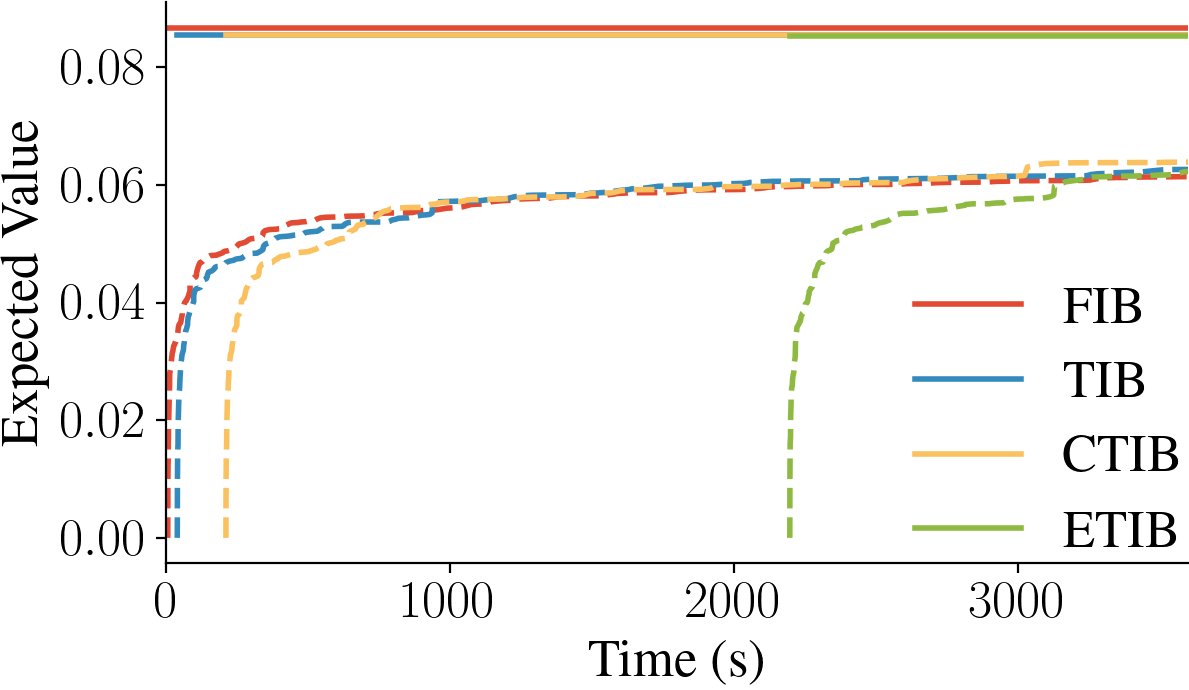

In [ ]:
colours =  ['#E24A33', '#348ABD',  '#FBC15E', '#8EBA42', '#FFB5B8']
filename = "Data/Figures/SarsopTest_fourth.pdf"


ts, ubs, lbs, solvernames, envname = get_data_plot("fourth", solvers=["SARSOP", "TIB-SARSOP", "CTIB-SARSOP", "ETIB-SARSOP"])
plt.figure(figsize=(6.5, 4)) 

for (i,label) in enumerate(solvernames):
    label = solver_to_heuristic[label]
    plt.plot(ts[i],ubs[i], label=label, color=colours[i], linestyle="-")
    plt.plot(ts[i],lbs[i], label=None, color=colours[i], linestyle="--")
    # x,y  = ts[i][-1], (ubs[i][-1] + lbs[i][-1])/2
    # plt.plot(x,y, marker="o", markersize=15, label=None, color=colours[i])
    # x,y  = ts[i][-1], lbs[i][-1]
    # plt.plot(x,y, marker="X", markersize=10, label=None, color=colours[i])

plt.xlabel("Time (s)")
plt.ylabel("Expected Value")

# plt.ylim(-1.8, -1.2)
plt.xlim(0,3600)
plt.legend()
plt.savefig(filename, transparent=True)
plt.show()

In [ ]:
# colours =  ['#E24A33', '#348ABD',  '#FBC15E', '#8EBA42', '#FFB5B8']
# filename = "Data/Figures/SarsopTest_K-out-of-N2.pdf"


# ts, ubs, lbs, solvernames, envname = get_data_plot("K-out-of-N2", solvers=["SARSOP", "TIB-SARSOP", "CTIB-SARSOP", "ETIB-SARSOP"])
# plt.figure(figsize=(6.5, 4)) 

# for (i,label) in enumerate(solvernames):
#     label = solver_to_heuristic[label]
#     plt.plot(ts[i],ubs[i], label=label, color=colours[i], linestyle="-")
#     plt.plot(ts[i],lbs[i], label=None, color=colours[i], linestyle="--")
#     # x,y  = ts[i][-1], (ubs[i][-1] + lbs[i][-1])/2
#     # plt.plot(x,y, marker="o", markersize=15, label=None, color=colours[i])
#     # x,y  = ts[i][-1], lbs[i][-1]
#     # plt.plot(x,y, marker="X", markersize=10, label=None, color=colours[i])

# plt.xlabel("Time (s)")
# plt.ylabel("Expected Value")

# plt.ylim(-1.8, -1.4)
# plt.xlim(0,120)
# plt.legend()
# plt.savefig(filename, transparent=True)
# plt.show()

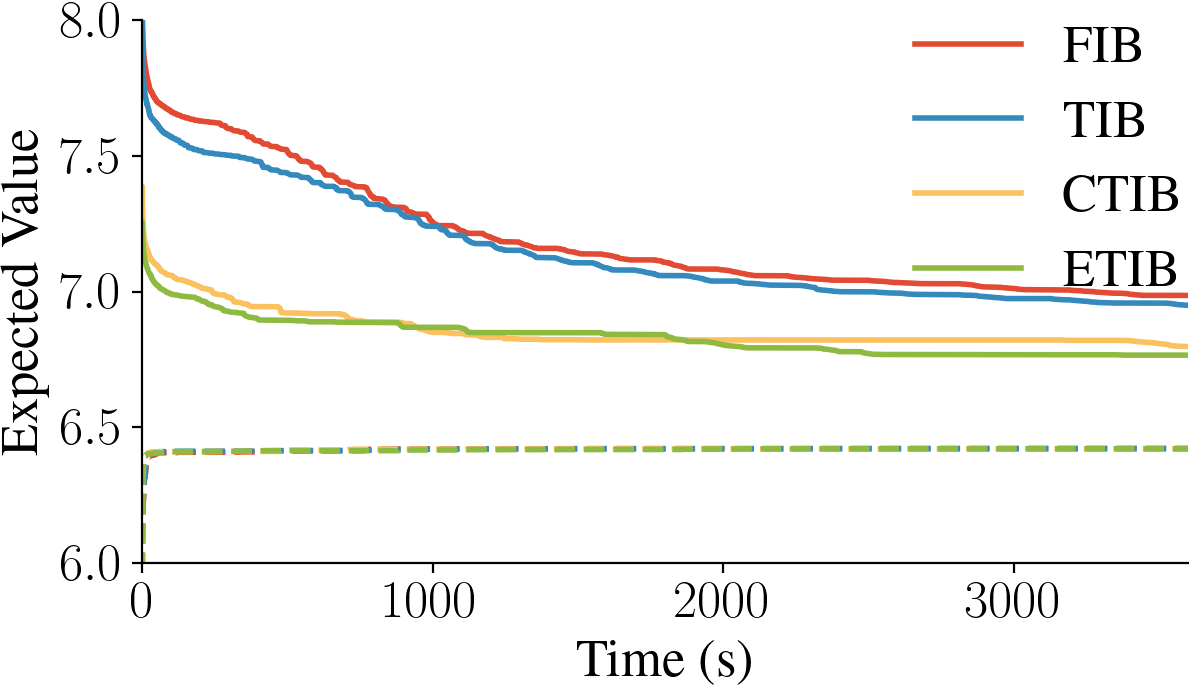

In [ ]:
colours =  ['#E24A33', '#348ABD',  '#FBC15E', '#8EBA42', '#FFB5B8']
filename = "Data/Figures/SarsopTest_grid.pdf"


ts, ubs, lbs, solvernames, envname = get_data_plot("grid", solvers=["SARSOP", "TIB-SARSOP", "CTIB-SARSOP", "ETIB-SARSOP"])
plt.figure(figsize=(6.5, 4)) 

for (i,label) in enumerate(solvernames):
    label = solver_to_heuristic[label]
    plt.plot(ts[i],ubs[i], label=label, color=colours[i], linestyle="-")
    plt.plot(ts[i],lbs[i], label=None, color=colours[i], linestyle="--")
    # x,y  = ts[i][-1], (ubs[i][-1] + lbs[i][-1])/2
    # plt.plot(x,y, marker="o", markersize=15, label=None, color=colours[i])
    # x,y  = ts[i][-1], lbs[i][-1]
    # plt.plot(x,y, marker="X", markersize=10, label=None, color=colours[i])

plt.xlabel("Time (s)")
plt.ylabel("Expected Value")

plt.ylim(6, 8)
plt.xlim(0,3600)
plt.legend()
plt.savefig(filename, transparent=True)
plt.show()


In [ ]:
# ### K-out-of-N2

# filename = "Data/Figures/SarsopTest_FrozenLake10.pdf"
# ts, ubs, lbs, solvernames, envname = get_data_plot("Tag")

# for (i,solver) in enumerate(solvernames):
#     label = solver_to_heuristic[solver]
#     # label = solver
#     plt.plot(ts[i],ubs[i], label=label, color=colours[i], linestyle="-")
#     plt.plot(ts[i],lbs[i], label=None, color=colours[i], linestyle="--")
#     # x,y  = ts[i][-1], (ubs[i][-1] + lbs[i][-1])/2
#     # plt.plot(x,y, marker="o", markersize=15, label=None, color=colours[i])
#     # x,y  = ts[i][-1], lbs[i][-1]
#     # plt.plot(x,y, marker="X", markersize=10, label=None, color=colours[i])

# plt.xlabel("Time (s)")
# plt.ylabel("Initial Value")

# plt.ylim(-12, -4)
# # plt.xlim(0, 60)
# plt.legend()
# plt.savefig(filename, transparent=True)
# plt.show()

# Discount Plotting

In [ ]:
# FrozenLake5
filename = "Data/Figures/DiscountTest_RockSample5.pdf"
discounts = np.arange(0.95, 0.998, 0.001)
times, init_times, snames = get_data_discounts("RockSample5", discounts)

solvernames = ["FIB", "TIB", "ETIB"]

# plt.axhline(y=3600, label="TO", linestyle="--", color="0.5")
plt.figure(figsize=(6, 4)) 
for (i,solver) in enumerate(solvernames):
    plt.plot(discounts[0:len(times[i])],times[i], label=solver, color=colours[i], linestyle="-")

# Swithc TO to last on legend
handles, labels = plt.gca().get_legend_handles_labels()
# to_index = labels.index("TO")
# handles.append(handles.pop(to_index))
# labels.append(labels.pop(to_index))

plt.yscale("log")
plt.xlabel("Discount")
plt.ylabel("Computation time (s)")

plt.xlim(0.95, 1)
plt.legend(handles, labels, loc='center left')
plt.title("RockSample (5,3)")

plt.savefig(filename, transparent=True)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './Data/DiscountTest/Sarsoptest_RockSample5_CTIB-SARSOP_t3600_d95.json'

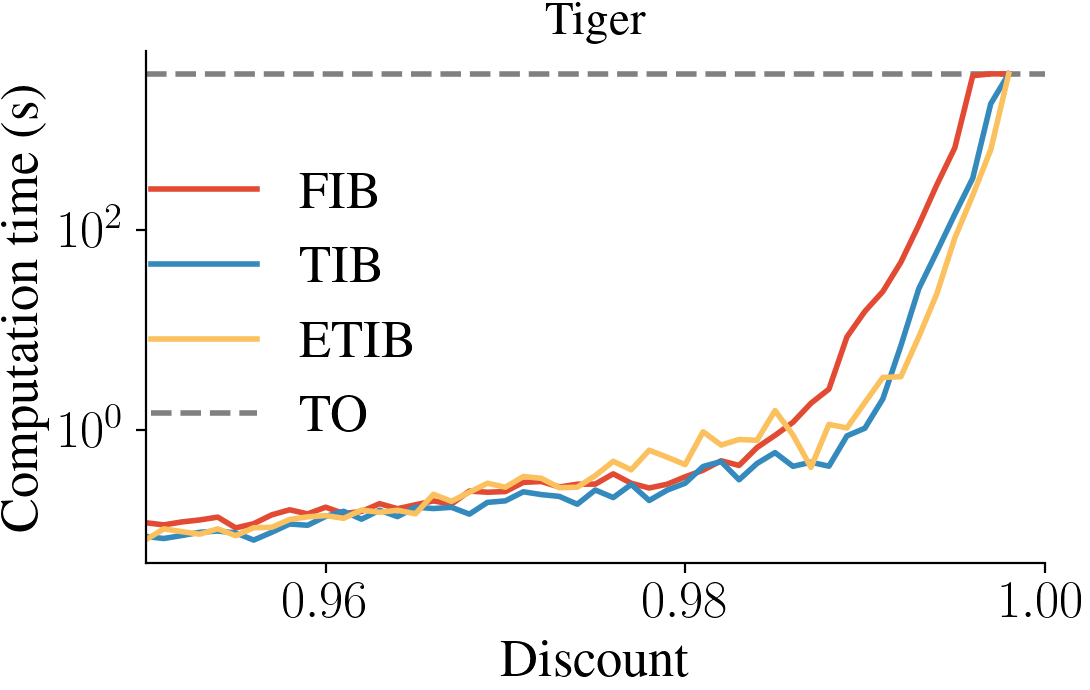

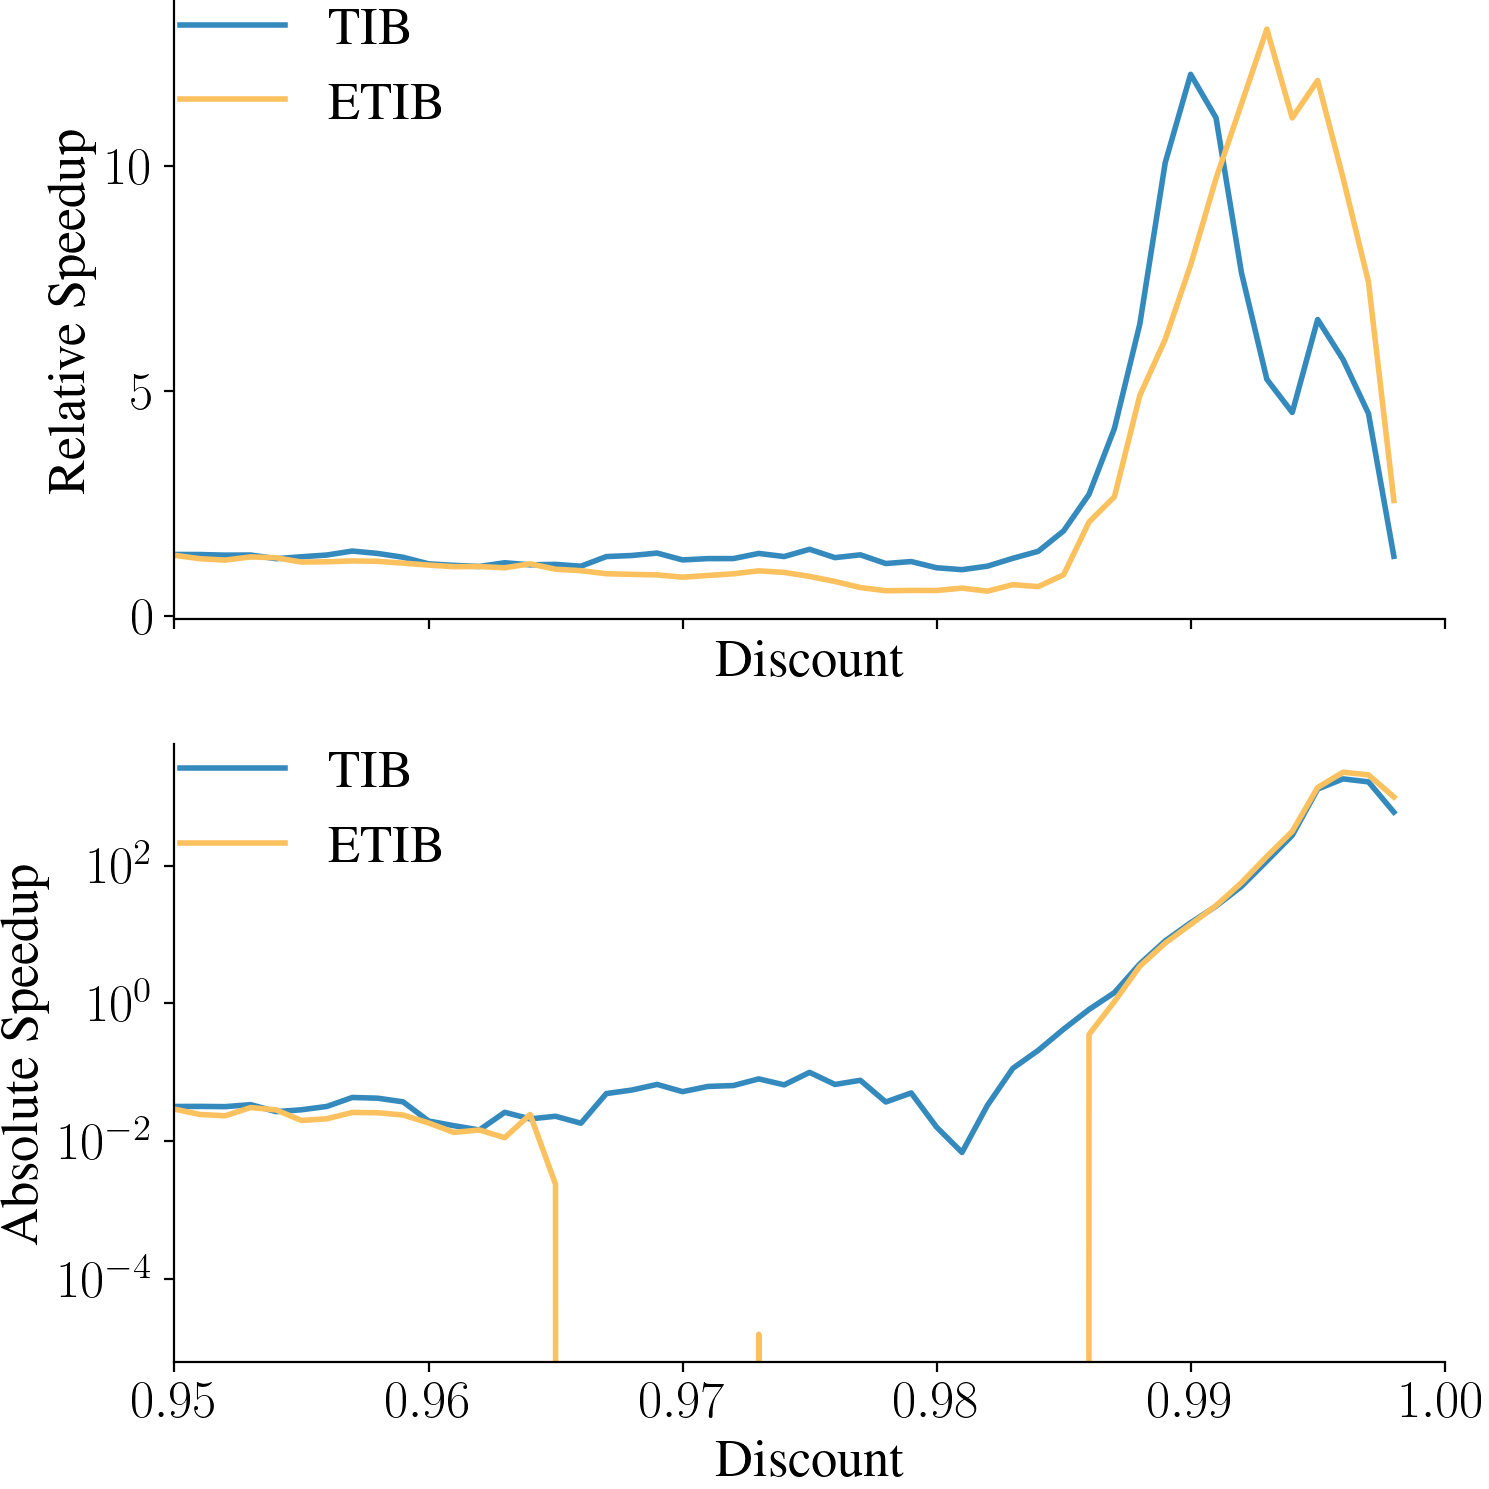

In [ ]:
# Tiger
filename = "Data/Figures/DiscountTest_Tiger.pdf"
discounts = np.arange(0.95, 0.998, 0.001)
times, init_times, snames = get_data_discounts("Tiger", discounts)

solvernames = ["FIB", "TIB", "ETIB"]

plt.figure(figsize=(6, 4)) 

plt.axhline(y=3600, label="TO", linestyle="--", color="0.5")

for (i,solver) in enumerate(solvernames):
    plt.plot(discounts[0:len(times[i])],times[i], label=solver, color=colours[i], linestyle="-")

# Swithc TO to last on legend
handles, labels = plt.gca().get_legend_handles_labels()
to_index = labels.index("TO")
handles.append(handles.pop(to_index))
labels.append(labels.pop(to_index))

plt.yscale("log")
plt.xlabel("Discount")
plt.ylabel("Computation time (s)")

plt.xlim(0.95, 1)
plt.legend(handles, labels, loc='center left')
plt.title("Tiger")
plt.savefig(filename, transparent=True)
plt.show()

# cut out part where FIB times out:
for i in range(len(times)):
    times[i] = times[i][0:len(times[0])]
discounts = discounts[0:len(times[0])]

# for i in range(len(times)):
#     times[i] = times[i][mask]

speedup_rel_TIB = savgol_filter(np.divide(times[0], times[1]), window_length=3, polyorder=0, mode="nearest")
speedup_rel_ETIB = savgol_filter(np.divide(times[0], times[2]), window_length=3, polyorder=0, mode="nearest")
speedup_abs_TIB = savgol_filter(np.subtract(times[0], times[1]), window_length=3, polyorder=0, mode="nearest")
speedup_abs_ETIB = savgol_filter(np.subtract(times[0], times[2]), window_length=3, polyorder=0, mode="nearest")
# plt.xlim(0.95, 1)
# # plt.ylim(0,25)
# plt.plot(discounts,speedup_rel_TIB, color=colours[1], linestyle="-", label="TIB")
# plt.plot(discounts,speedup_rel_ETIB, color=colours[2], linestyle="-", label="ETIB")
# plt.legend(loc="upper left")
# plt.xlabel("Discount")
# plt.ylabel("Relative Speedup")
# plt.savefig("Data/Figures/DiscountTest_Tiger_relspeedup.pdf")
# plt.show()
# plt.xlim(0.95, 1)
# # plt.ylim(0,1000)
# plt.plot(discounts,speedup_abs_TIB, color=colours[1], linestyle="-", label="TIB")
# plt.plot(discounts,speedup_abs_ETIB, color=colours[2], linestyle="-", label="ETIB")
# plt.legend(loc="upper left")
# plt.xlabel("Discount")
# plt.ylabel("Absolute Speedup")
# plt.yscale("log")
# plt.savefig("Data/Figures/DiscountTest_Tiger_absspeedup.pdf")
# plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# First subplot: Relative Speedup
ax1.set_xlim(0.95, 1)
ax1.plot(discounts, speedup_rel_TIB, color=colours[1], linestyle="-", label="TIB")
ax1.plot(discounts, speedup_rel_ETIB, color=colours[2], linestyle="-", label="ETIB")
ax1.legend(loc="upper left")
# ax1.set_yscale("log")
ax1.set_xlabel("Discount")
ax1.set_ylabel("Relative Speedup")
# ax1.set_title("Relative Speedup vs Discount")  # Optional title for clarity

# Second subplot: Absolute Speedup
ax2.set_xlim(0.95, 1)
ax2.plot(discounts, speedup_abs_TIB, color=colours[1], linestyle="-", label="TIB")
ax2.plot(discounts, speedup_abs_ETIB, color=colours[2], linestyle="-", label="ETIB")
ax2.legend(loc="upper left")
ax2.set_xlabel("Discount")
ax2.set_ylabel("Absolute Speedup")
ax2.set_yscale("log")
# ax2.set_title("Absolute Speedup vs Discount")  # Optional title for clarity

# Adjust the layout so the plots don't overlap
plt.tight_layout()

# Save the figure if needed
plt.savefig("Data/Figures/DiscountTest_Tiger_speedup_subplots.pdf")

# Display the plots
plt.show()



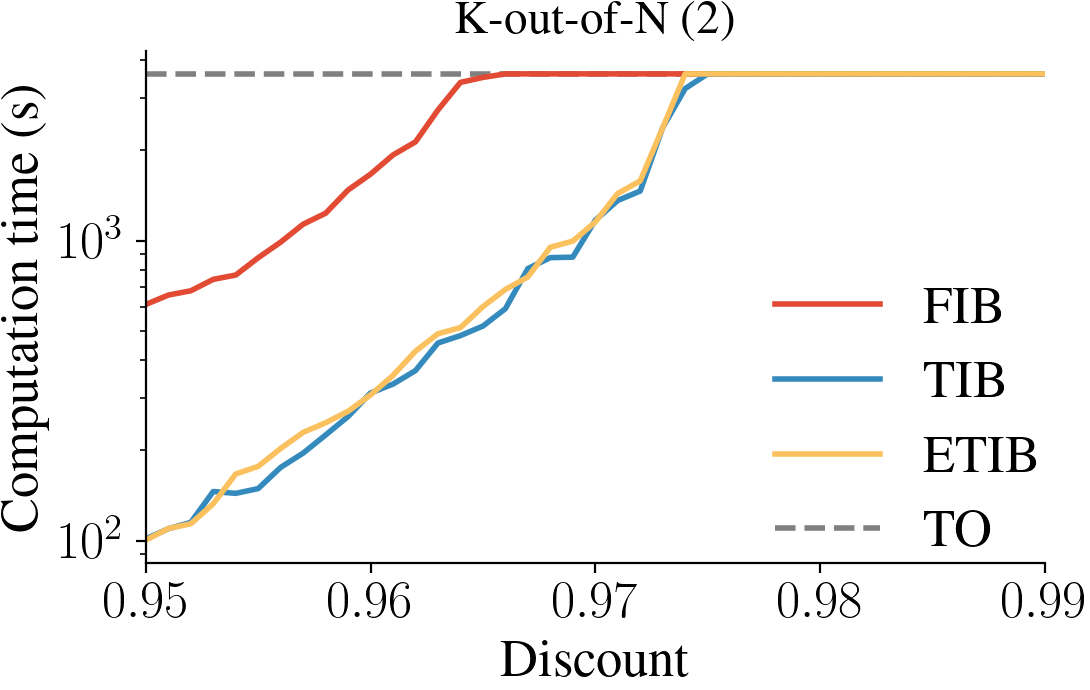

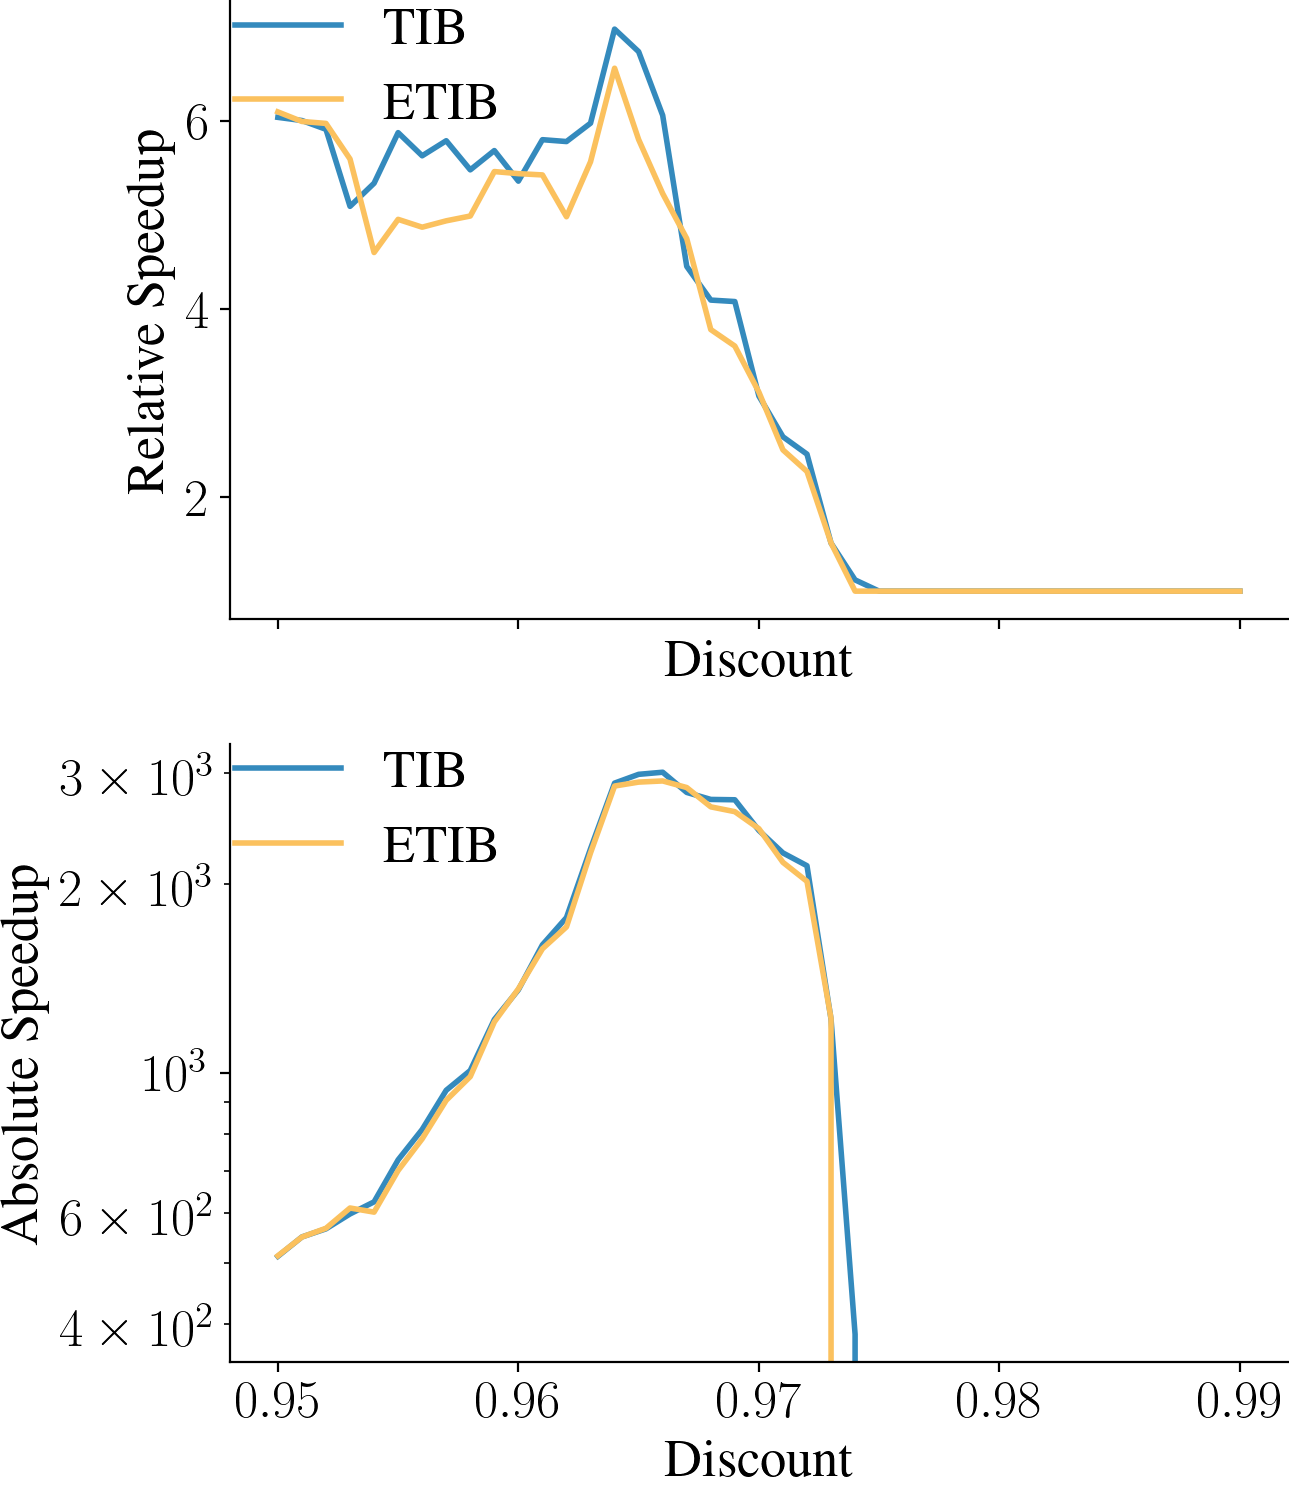

In [ ]:
# K-out-of-N2
filename = "Data/Figures/DiscountTest_K-out-of-N2.pdf"
discounts = np.arange(0.95, 0.990, 0.001)
times, init_times, snames = get_data_discounts("K-out-of-N2", discounts)

solvernames = ["FIB", "TIB", "ETIB"]

plt.figure(figsize=(6, 4)) 
plt.axhline(y=3600, label="TO", linestyle="--", color="0.5")

for (i,solver) in enumerate(solvernames):
    plt.plot(discounts[0:len(times[i])],times[i], label=solver, color=colours[i], linestyle="-")

# print(discounts[24])
# print(times[0][24])
# print(times[1][24])
# print(times[2][24])

# print(discounts[20])
# print(times[0][20])
# print(times[1][20])
# print(times[2][20])

# print(discounts[0])
# print(times[0][0])
# print(times[1][0])
# print(times[2][0])

# Swithc TO to last on legend
handles, labels = plt.gca().get_legend_handles_labels()
to_index = labels.index("TO")
handles.append(handles.pop(to_index))
labels.append(labels.pop(to_index))

plt.yscale("log")
plt.xlabel("Discount")
plt.ylabel("Computation time (s)")

plt.xlim(0.95, 0.99)
plt.legend(handles, labels, loc='best')
plt.title("K-out-of-N (2)")
plt.savefig(filename, transparent=True)
plt.show()

# cutoff = 16
# cut out part where FIB times out:
for i in range(len(times)):
    times[i] = times[i][0:len(times[0])]
discounts = discounts[0:len(times[0])]


# speedup_rel_TIB = savgol_filter(np.divide(times[0], times[1]), window_length=3, polyorder=0, mode="nearest")
# speedup_rel_ETIB = savgol_filter(np.divide(times[0], times[2]), window_length=3, polyorder=0, mode="nearest")
# speedup_abs_TIB = savgol_filter(np.subtract(times[0], times[1]), window_length=3, polyorder=0, mode="nearest")
# speedup_abs_ETIB = savgol_filter(np.subtract(times[0], times[2]), window_length=3, polyorder=0, mode="nearest")
speedup_rel_TIB = np.divide(times[0], times[1])
speedup_rel_ETIB = np.divide(times[0], times[2])
speedup_abs_TIB = np.subtract(times[0],times[1])
speedup_abs_ETIB = np.subtract(times[0],times[2])
# plt.xlim(0.95, 0.974)
# plt.ylim(0,25)
# plt.plot(discounts,speedup_rel_TIB)#, color=colours[i], linestyle="-")
# plt.plot(discounts,speedup_rel_ETIB)#, color=colours[i], linestyle="-")
# plt.show()
# # plt.xlim(0.95, 0.974)
# # plt.ylim(0,1000)
# plt.plot(discounts,speedup_abs_TIB)#, color=colours[i], linestyle="-")
# plt.plot(discounts,speedup_abs_ETIB)#, color=colours[i], linestyle="-")
# # plt.yscale("log")
# plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

# First subplot: Relative Speedup
# ax1.set_xlim(0.95, 1)
ax1.plot(discounts, speedup_rel_TIB, color=colours[1], linestyle="-", label="TIB")
ax1.plot(discounts, speedup_rel_ETIB, color=colours[2], linestyle="-", label="ETIB")
ax1.legend(loc="upper left")
# ax1.set_yscale("log")
ax1.set_xlabel("Discount")
ax1.set_ylabel("Relative Speedup")
# ax1.set_title("Relative Speedup vs Discount")  # Optional title for clarity

# Second subplot: Absolute Speedup
# ax2.set_xlim(0.95, 1)
ax2.plot(discounts, speedup_abs_TIB, color=colours[1], linestyle="-", label="TIB")
ax2.plot(discounts, speedup_abs_ETIB, color=colours[2], linestyle="-", label="ETIB")
ax2.legend(loc="upper left")
ax2.set_xlabel("Discount")
ax2.set_ylabel("Absolute Speedup")
ax2.set_yscale("log")
# ax2.yaxis.tick_right()
# ax2.yaxis.set_label_position("right")
# ax2.spines['right'].set_position(('outward', 0))  # Move the right spine outwards to become the primary y-axis
# ax2.spines['left'].set_visible(False)  # Hide the left y-axis spine
# ax2.spines['right'].set_visible(True)
ax2.set_ylabel("Absolute Speedup")
# ax2.set_title("Absolute Speedup vs Discount")  # Optional title for clarity

# Adjust the layout so the plots don't overlap
plt.tight_layout()

# Save the figure if needed
plt.savefig("Data/Figures/DiscountTest_K-out-of-N2_speedup_subplots.pdf")

# Display the plots
plt.show()



In [ ]:
# # Tiger
# filename = "Data/Figures/DiscountTest_K-out-of-N2_heuristic.pdf"
# discounts = np.arange(0.95, 0.998, 0.001)
# times, init_times, snames = get_data_discounts("Tiger", discounts)

# solvernames = ["FIB", "TIB", "ETIB"]

# # plt.axhline(y=3600, label="TO", linestyle="--", color="0.5")

# for (i,solver) in enumerate(solvernames):
#     plt.plot(discounts[0:len(init_times[i])],init_times[i], label=solver, color=colours[i], linestyle="-")

# # Swithc TO to last on legend
# handles, labels = plt.gca().get_legend_handles_labels()
# # to_index = labels.index("TO")
# # handles.append(handles.pop(to_index))
# # labels.append(labels.pop(to_index))

# # plt.yscale("log")
# plt.xlabel("Discount")
# plt.ylabel("Computation time")

# # plt.xlim(0.95, 0.99)
# plt.legend(handles, labels, loc='best')
# plt.title("K-out-of-N (2)")
# plt.savefig(filename, transparent=True)
# plt.show()